In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import catppuccin

df = pd.read_csv("../data/spotify_dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Dataset Info And Cleaning

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [18]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [19]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [20]:
df.shape

(114000, 20)

In [21]:
# null values
df.isna().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [22]:
df.dropna(subset=["artists", "album_name", "track_name"], how="any", inplace=True)
df.drop_duplicates(inplace=True, keep="first")

In [23]:
# basic stats
df.describe(include=["float64", "int64"])

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,0.567031,0.642091,5.309452,-8.243408,0.637866,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745,3.904218
std,22.283855,1.064131e+05,0.173409,0.251053,3.560147,5.011422,0.480620,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954,0.432117
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615880e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [24]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  str    
 1   artists           113549 non-null  str    
 2   album_name        113549 non-null  str    
 3   track_name        113549 non-null  str    
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           113549 non-null  f

In [25]:
# fixing columns
df.columns = df.columns.str.replace("_", " ", regex=False).str.title()

In [26]:
# creating artist df
artists_df = df.copy()
artists_df.Artists = df.Artists.str.split(";")
artists_df = artists_df.explode("Artists")
artists_df.Artists = artists_df.Artists.str.strip()

In [27]:
# cleaned dataset
df.head()

,Track Id,Artists,Album Name,Track Name,Popularity,Duration Ms,Explicit,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Track Genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Popularity Analysis

What features correlate with popularity?

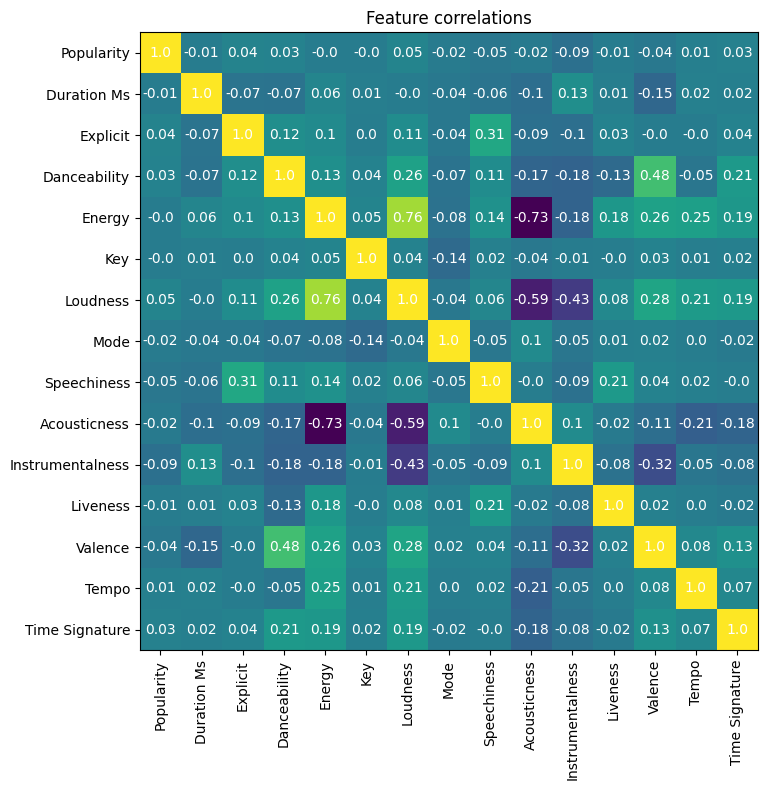

In [28]:
features_corrs = df.corr(numeric_only=True, method="pearson")

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(features_corrs.values)

ax.set_xticks(range(len(features_corrs.index)), labels=features_corrs.index, rotation=90)
ax.set_yticks(range(len(features_corrs.index)), labels=features_corrs.index)

for i in range(len(features_corrs.index)):
    for j in range(len(features_corrs.index)):
        text = ax.text(j, i, round(features_corrs.iloc[i, j], 2), ha="center", va="center", color="white")

ax.set_title("Feature correlations")
fig.tight_layout()

Are energetic songs more popular?

In [29]:
df["Energy"].corr(df["Popularity"], method="pearson")

np.float64(-0.0024469965919801952)

## Audio Feature Relationship Analysis

Is energy correlated with loudness?

Text(0, 0.5, 'Loudness')

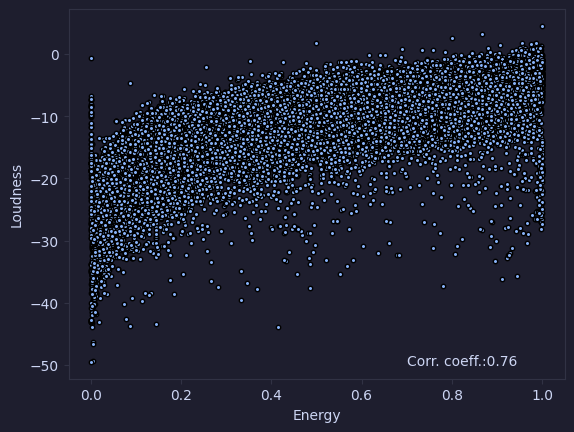

In [30]:
mpl.style.use("mocha")
energy_loudness_corr = df.Energy.corr(df.Loudness, method="pearson")

plt.scatter(df.Energy, df.Loudness, s=10, edgecolor="black")
plt.text(x=0.7, y=-50, s=f"Corr. coeff.:{np.round(energy_loudness_corr, 2)}")
plt.xlabel("Energy")
plt.ylabel("Loudness")

Are acoustic songs less energetic?

Text(0, 0.5, 'Energy')

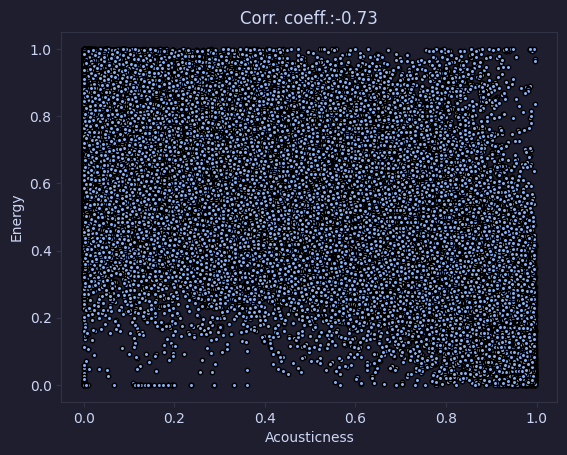

In [31]:
acoustic_energy_corr = df.Acousticness.corr(df.Energy, method="pearson")

plt.scatter(df.Acousticness, df.Energy, s=10, edgecolor="black")
plt.title(f"Corr. coeff.:{np.round(acoustic_energy_corr, 2)}")
plt.xlabel("Acousticness")
plt.ylabel("Energy")

## Distribution Analysis

Are tempos normally distributed?

Text(0.5, 1.0, 'Tempo Histogram')

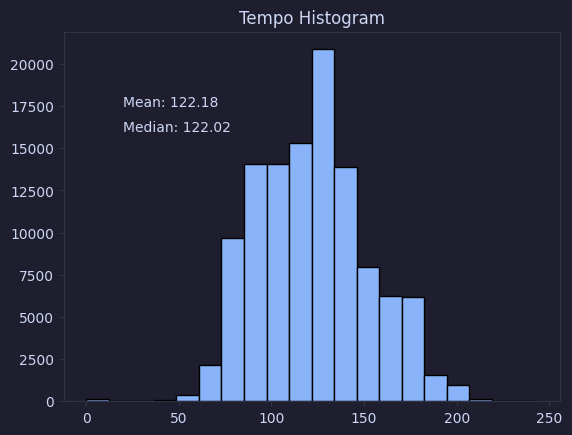

In [32]:
tempos_stats = df.Tempo.agg(["mean", "median"]).round(2)
plt.hist(df.Tempo, edgecolor="black", bins=20)
plt.text(x=20, y=17500, s=f"Mean: {tempos_stats["mean"]}")
plt.text(x=20, y=16000, s=f"Median: {tempos_stats["median"]}")
plt.title("Tempo Histogram")

Is popularity skewed?

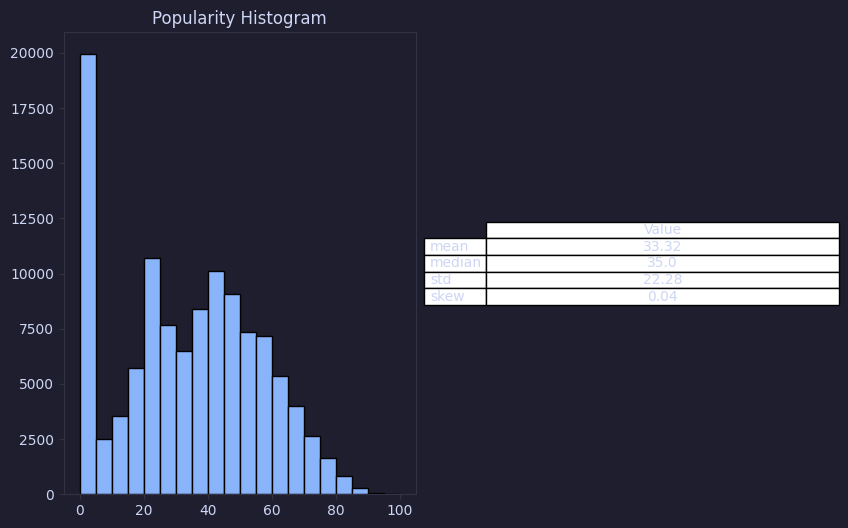

In [33]:
popularity_stats = df.Popularity.agg(["mean", "median", np.std, "skew"])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes[0].hist(df.Popularity, edgecolor="black", bins=20)
axes[0].set_title("Popularity Histogram")
axes[1].set_axis_off()
axes[1].table(cellText=[[round(stat, 2)] for stat in popularity_stats.values], cellLoc="center", rowLabels=popularity_stats.index, rowLoc="left", colLabels=["Value"], colLoc="center", loc="center")

## Explicit vs. Non-explicit songs

Are explicit songs more popular? More energetic?

In [34]:
explicit_popularity_means = df.groupby("Explicit")["Popularity"].mean()
explicit_energy_means = df.groupby("Explicit")["Energy"].mean()

print(explicit_popularity_means)
print(explicit_energy_means)

Explicit
False    33.024896
True     36.524799
Name: Popularity, dtype: float64
Explicit
False    0.634698
True     0.721080
Name: Energy, dtype: float64


## Artist Analysis

Which artists dominate popularity?

Text(0.5, 1.0, 'Popularity-dominating artists')

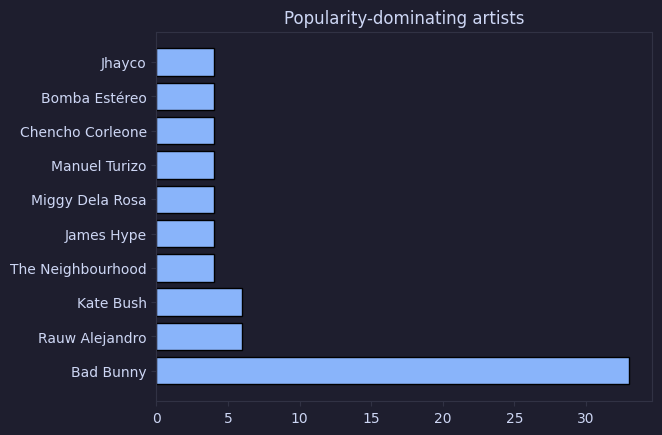

In [35]:
dominating_artists = artists_df[artists_df.Popularity >= 90]["Artists"].value_counts().nlargest(10)

plt.barh(dominating_artists.index, dominating_artists.values, edgecolor="black")
plt.title("Popularity-dominating artists")

Which artists have most songs?

Text(0.5, 1.0, 'Artists with the most songs')

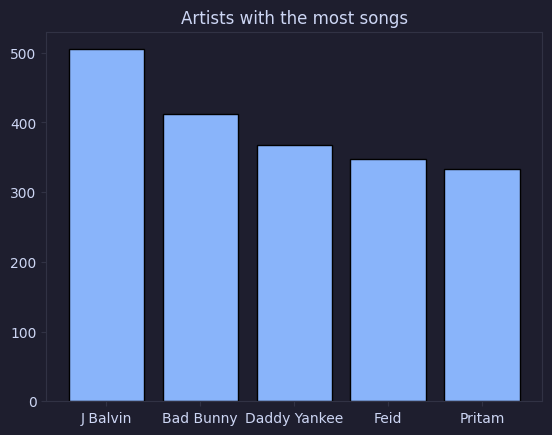

In [36]:
artists_most_songs = artists_df.groupby("Artists").size().sort_values(ascending=False).head(5)

plt.bar(artists_most_songs.index, artists_most_songs.values, edgecolor="black")
plt.title("Artists with the most songs")

## Genre Analysis

Which genres are most common?

In [37]:
df["Track Genre"].value_counts(normalize=True)

Track Genre
acoustic      0.008807
british       0.008807
country       0.008807
disco         0.008807
electronic    0.008807
                ...   
honky-tonk    0.008639
dance         0.008499
german        0.008481
classical     0.008217
romance       0.007961
Name: proportion, Length: 114, dtype: float64

Which genres are more popular?

Text(0.5, 1.0, 'Most popular genres')

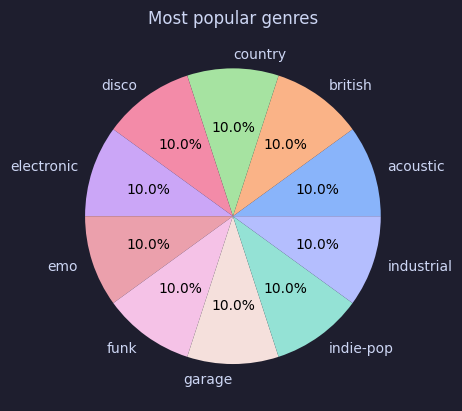

In [38]:
track_genres = df["Track Genre"].value_counts(normalize=True).head(10)
patches, texts, autotexts = plt.pie(track_genres, labels=track_genres.index, autopct="%1.1f%%")

for autotext in autotexts:
    autotext.set_color("black")

plt.title("Most popular genres")

## Machine Learning Models (predict popularity)

Multiple Linear Regression

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["Duration Ms", "Danceability", "Energy", "Loudness", "Speechiness", "Acousticness", "Instrumentalness", "Liveness", "Valence", "Tempo"]]
y = df.Popularity

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

predictions = regressor.predict(X_test)

mae_regressor = mean_absolute_error(y_test, predictions)
r2_score_regressor = r2_score(y_test, predictions)

print(f"Regressor MAE: {np.round(mae_regressor, 2)}")
print(f"Regressor R² score: {np.round(r2_score_regressor, 2)}")


Regressor MAE: 18.49
Regressor R² score: 0.02


Text(0.5, 1.0, 'Multiple Regression Residuals')

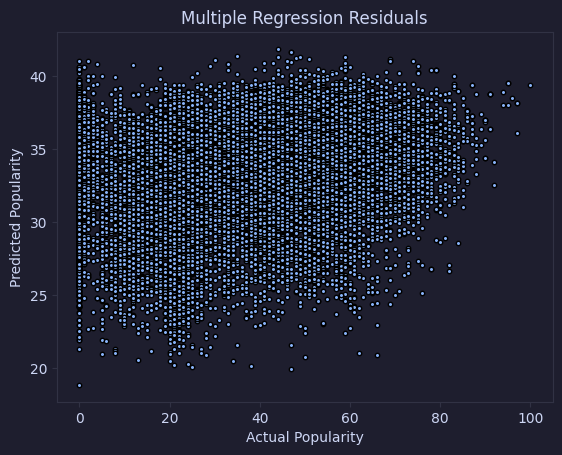

In [40]:
# plotting residuals
plt.scatter(y_test, predictions, edgecolor="black", s=10)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Multiple Regression Residuals")


Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, rf_predictions)
r2_score_rf = r2_score(y_test, rf_predictions)

print(f"Random Forest Regressor MAE: {np.round(mae_rf, 2)}")
print(f"Random Forest Regressor R² score: {np.round(r2_score_rf, 2)}")

Random Forest Regressor MAE: 10.78
Random Forest Regressor R² score: 0.54


Text(0.5, 1.0, 'Random Forest Regressor Residuals')

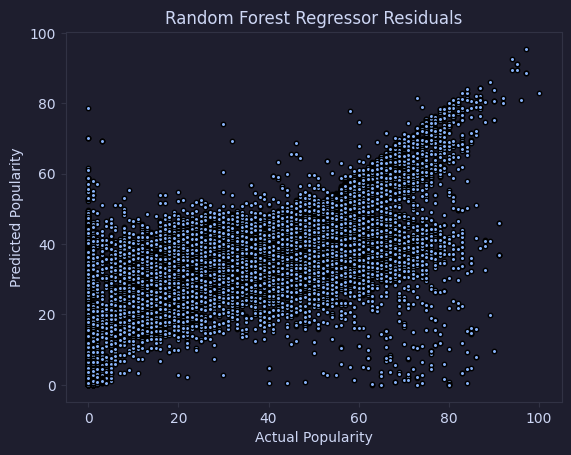

In [42]:
# plotting residuals
plt.scatter(y_test, rf_predictions, edgecolor="black", s=10)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Random Forest Regressor Residuals")

## Conclusions

### Data Analysis

1. Popularity showed weak linear correlations with most individual variables.
2. Energy and loudness showed a strong positive correlation (0.76).
3. Tempos are close to normally distributed, having a mean of 122.2 and a median of 122. Furthermore, popularity is skewed to the right, indicating that while most songs have moderate popularity, a smaller number of tracks achieve very high popularity.
4. The data suggests that explicit songs are more popular and more energetic, on average, than non-explicit ones.
5. Bad Bunny appeared most frequently in the dataset, followed by Rauw Alejandro and Kate Bush. This doesn’t indicate Spotify’s user preferences necessarily as the data is sampled.
6. J Balvin is the artist with the most songs in the dataset.
7. There aren’t genres more common than others in the dataset. This suggests that the author of the dataset decided to include all genres, in roughly equal proportions.

### Machine Learning

8. Between multiple linear regression and random forest regression to predict popularity, the latter performed better as seen by:
-	Lower mean absolute error: 10.78 vs 18.49
-	Higher R² score: 0.54 vs 0.02

Furthermore, the low R² score and high MAE for multiple regression suggest that the model suffers from high bias, meaning the model is too simple to learn the real pattern. The model underfits the data. 